# **vaporspec: Longwave Radiation & Humidity Analysis**
### *Presentation Demo Notebook*

This notebook demonstrates the core workflow of the `vaporspec` package:

- Load ERA5 + CU ATOC data  
- Merge and preprocess  
- Compute key diagnostics  
- Visualize physical relationships  
- Summarize results  

All cells are pre‑run for presentation purposes.


## **1. Introduction**

This project analyzes how **humidity** and **cloudiness** influence **longwave radiation** using:

- ERA5 reanalysis (September 2020)
- CU ATOC surface station data

The goal is to provide a clean, reproducible workflow packaged as `vaporspec`.


In [154]:
import vaporspec as vs
import matplotlib.pyplot as plt

## **2. Load Data**

We load one month of ERA5 + CU ATOC data.  
This is enough for:

- Diurnal cycles  
- Humidity–LW relationships  
- Cloud mask statistics  


### **2.1 Surface Station Data**

Load the CU ATOC September 2020 dataset.

In [155]:
df_cu = vs.io.load_cu_atoc("data/cu_atoc_sept2020/cu_atoc_sept2020.csv")
df_cu.head()

,Date,Time,Temp_Out,Temp_Hi,Temp_Low,Hum_Out,Dew_Out,Wind_Speed,Wind_Dir,Wind_Run,...,In_Heat,EMC,Air_Density,Wind_Samp,Wind_Tx,ISS_Recept,Arc_Int,time,Temp_Out_C,Dew_Out_C
0,8/31/20,12:05AM,61.3,61.6,61.0,50,42.5,14.0,NE,1.17,...,64.3,7.35,0.0618,117,1,100.0,5,2020-08-31 00:05:00,16.277778,5.833333
1,8/31/20,12:10AM,60.7,61.0,60.2,51,42.5,11.0,N,0.92,...,63.9,7.35,0.0619,116,1,100.0,5,2020-08-31 00:10:00,15.944444,5.833333
2,8/31/20,12:15AM,59.7,60.2,59.2,50,41.0,10.0,NNE,0.83,...,63.5,7.35,0.0620,114,1,100.0,5,2020-08-31 00:15:00,15.388889,5.000000
3,8/31/20,12:20AM,58.8,59.2,58.4,51,40.7,11.0,NNE,0.92,...,63.1,7.35,0.0620,114,1,100.0,5,2020-08-31 00:20:00,14.888889,4.833333
4,8/31/20,12:25AM,58.2,58.4,57.9,52,40.6,8.0,NNE,0.67,...,62.8,7.35,0.0621,115,1,100.0,5,2020-08-31 00:25:00,14.555556,4.777778


### **2.2 ERA5 Data**

Load ERA5 longwave radiation, cloud fraction, humidity, and temperature fields.

In [156]:
ds_era5 = vs.io.load_era5(
    radiation_file="data/ERA5_sept2020/era5_singlelevel_radiation_accum_sept2020.nc",
    cloud_file="data/ERA5_sept2020/era5_singlelevel_cloud_sp_sept2020.nc",
    pressure_file="data/ERA5_sept2020/era5_pressure_humidity_temperature_sept2020.nc"
)
ds_era5

<xarray.Dataset> Size: 52kB
Dimensions:         (valid_time: 720, latitude: 1, longitude: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2020-09-01 ... 2020-09-30...
  * latitude        (latitude) float64 8B 40.0
  * longitude       (longitude) float64 16B -105.2 -105.0
    number          int64 8B 0
    pressure_level  float64 8B 850.0
    expver          (valid_time) <U4 12kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    q850            (valid_time, latitude, longitude) float32 6kB ...
    t850            (valid_time, latitude, longitude) float32 6kB ...
    sp              (valid_time, latitude, longitude) float32 6kB ...
    tcc             (valid_time, latitude, longitude) float32 6kB ...
    strd            (valid_time, latitude, longitude) float32 6kB ...
    str             (valid_time, latitude, longitude) float32 6kB ...

## **3. Merge & Preprocess**

We merge the surface and ERA5 datasets and apply a cloud mask.

Steps:

- Align timestamps  
- Interpolate ERA5 to station location  
- Add cloud mask classification  

### **3.1 Merge Datasets**

Combine surface and ERA5 variables into a single DataFrame.

In [157]:
df = vs.io.merge_cu_era5(df_cu, ds_era5)
df.head()

,Date,Time,Temp_Out,Temp_Hi,Temp_Low,Hum_Out,Dew_Out,Wind_Speed,Wind_Dir,Wind_Run,...,longitude,number,pressure_level,expver,q850,t850,sp,tcc,strd,str
0,8/31/20,6:00PM,69.3,69.3,69.2,51,50.4,0.0,---,0.00,...,-105.25,0,850.0,0001,0.008074,293.717163,79440.6875,1.000000,1208958.0,-332989.5000
1,8/31/20,6:00PM,69.3,69.3,69.2,51,50.4,0.0,---,0.00,...,-105.00,0,850.0,0001,0.007900,295.820679,83121.6875,1.000000,1273246.0,-349021.5000
2,8/31/20,7:00PM,67.3,67.4,67.1,59,52.5,0.0,---,0.00,...,-105.25,0,850.0,0001,0.009713,292.277557,79475.1250,0.991333,1202651.0,-274373.8125
3,8/31/20,7:00PM,67.3,67.4,67.1,59,52.5,0.0,---,0.00,...,-105.00,0,850.0,0001,0.009361,294.107635,83194.1250,0.996643,1252731.0,-304773.8125
4,8/31/20,8:00PM,65.4,65.5,65.4,51,46.8,5.0,NNW,0.42,...,-105.25,0,850.0,0001,0.010912,291.481873,79578.5000,0.942261,1227151.0,-182570.8125


### **3.2 Apply Cloud Mask**

Classify each timestep as:

- **Clear-sky**
- **Cloudy**

based on ERA5 total cloud cover.

In [158]:
df = vs.io.compute_surface_specific_humidity(df)
df.head()


,Date,Time,Temp_Out,Temp_Hi,Temp_Low,Hum_Out,Dew_Out,Wind_Speed,Wind_Dir,Wind_Run,...,number,pressure_level,expver,q850,t850,sp,tcc,strd,str,q_surface
0,8/31/20,6:00PM,69.3,69.3,69.2,51,50.4,0.0,---,0.00,...,0,850.0,0001,0.008074,293.717163,79440.6875,1.000000,1208958.0,-332989.5000,0.000093
1,8/31/20,6:00PM,69.3,69.3,69.2,51,50.4,0.0,---,0.00,...,0,850.0,0001,0.007900,295.820679,83121.6875,1.000000,1273246.0,-349021.5000,0.000093
2,8/31/20,7:00PM,67.3,67.4,67.1,59,52.5,0.0,---,0.00,...,0,850.0,0001,0.009713,292.277557,79475.1250,0.991333,1202651.0,-274373.8125,0.000101
3,8/31/20,7:00PM,67.3,67.4,67.1,59,52.5,0.0,---,0.00,...,0,850.0,0001,0.009361,294.107635,83194.1250,0.996643,1252731.0,-304773.8125,0.000101
4,8/31/20,8:00PM,65.4,65.5,65.4,51,46.8,5.0,NNW,0.42,...,0,850.0,0001,0.010912,291.481873,79578.5000,0.942261,1227151.0,-182570.8125,0.000081


In [159]:
df_clear = vs.io.filter_clear_sky(df)
df_clear.head()

,Date,Time,Temp_Out,Temp_Hi,Temp_Low,Hum_Out,Dew_Out,Wind_Speed,Wind_Dir,Wind_Run,...,number,pressure_level,expver,q850,t850,sp,tcc,strd,str,q_surface
42,9/01/20,8:00AM,55.6,55.7,55.4,71,46.3,5.0,WSW,0.42,...,0,850.0,0001,0.009431,288.462280,79757.7500,0.120697,1.001558e+06,-306061.0000,0.000079
43,9/01/20,8:00AM,55.6,55.7,55.4,71,46.3,5.0,WSW,0.42,...,0,850.0,0001,0.009315,287.557983,83544.7500,0.168488,1.049878e+06,-320205.0000,0.000079
44,9/01/20,8:00AM,55.6,55.7,55.4,71,46.3,5.0,WSW,0.42,...,0,850.0,0001,0.009431,288.462280,79757.7500,0.120697,1.001558e+06,-306061.0000,0.000079
45,9/01/20,8:00AM,55.6,55.7,55.4,71,46.3,5.0,WSW,0.42,...,0,850.0,0001,0.009315,287.557983,83544.7500,0.168488,1.049878e+06,-320205.0000,0.000079
46,9/01/20,9:00AM,61.6,61.8,61.3,53,44.3,4.0,S,0.33,...,0,850.0,0001,0.008994,288.997223,79729.3125,0.091156,1.060004e+06,-319922.0625,0.000074


## **4. Diagnostics**

Compute key metrics used in the analysis:

- Humidity‑binned LW↓ comparison  
- Diurnal cycle  
- Cloud mask statistics  

### **4.1 Humidity‑Binned Comparison**

Group LW↓ by humidity bins to examine how moisture modulates longwave radiation.

In [160]:
bins = vs.analysis.humidity_binned_comparison(df)
bins

{'low_mean': np.float32(-333674.3),
 'low_ci': (np.float64(-353736.57547997066), np.float64(-313612.04952002934)),
 'high_mean': np.float32(-263873.0),
 'high_ci': (np.float64(-274388.3546342629), np.float64(-253357.64536573706))}

### **4.2 Diurnal Cycle**

Compute hourly means to reveal daily patterns in LW↓ and humidity.

In [161]:
diurnal = vs.analysis.diurnal_cycle(df)
diurnal

,Temp_Out,Temp_Hi,Temp_Low,Hum_Out,Dew_Out,Wind_Speed,Wind_Run,Wind_Hi_Speed,Wind_Chill,Heat_Index,...,longitude,number,pressure_level,q850,t850,sp,tcc,strd,str,q_surface
hour,,,,,,,,,,,,,,,,,,,,,
0,57.850000,58.060000,57.620000,52.333333,37.946667,3.333333,0.278333,6.500000,57.376667,55.926667,...,-105.125,0.0,850.0,0.006435,292.952148,82159.984375,0.283378,1.042808e+06,-258207.687500,0.000059
1,57.155932,57.344068,56.969492,53.101695,37.801695,3.559322,0.295763,6.966102,56.488136,55.408475,...,-105.125,0.0,850.0,0.006408,292.563507,82160.507812,0.316547,1.033143e+06,-255460.234375,0.000058
2,55.408475,55.649153,55.157627,54.661017,37.413559,3.118644,0.260169,6.118644,55.050847,53.716949,...,-105.125,0.0,850.0,0.006320,292.239899,82151.828125,0.315646,1.026497e+06,-253508.453125,0.000057
3,54.483051,54.642373,54.328814,56.983051,37.486441,2.610169,0.217797,5.694915,54.042373,52.945763,...,-105.125,0.0,850.0,0.006215,291.878662,82142.273438,0.243843,1.023646e+06,-250056.562500,0.000057
4,53.347458,53.516949,53.189831,58.220339,37.015254,3.000000,0.250169,6.101695,52.823729,51.928814,...,-105.125,0.0,850.0,0.005916,290.592621,82159.976562,0.272323,1.013827e+06,-252489.984375,0.000056
5,51.274576,51.391525,51.122034,63.101695,37.620339,1.898305,0.157627,4.508475,50.935593,50.133898,...,-105.125,0.0,850.0,0.005791,290.514587,82175.234375,0.248310,1.009047e+06,-250836.109375,0.000057
6,50.223729,50.369492,50.089831,65.847458,37.845763,1.440678,0.120169,3.627119,49.942373,49.216949,...,-105.125,0.0,850.0,0.005688,290.370361,82192.976562,0.254824,1.001796e+06,-252588.390625,0.000058
7,49.994915,50.111864,49.876271,65.949153,37.403390,1.830508,0.152712,4.135593,49.659322,48.996610,...,-105.125,0.0,850.0,0.005609,290.288025,82221.828125,0.275578,9.929364e+05,-254462.796875,0.000057
8,54.042373,54.301695,53.791525,60.406780,38.910169,2.237288,0.186441,4.661017,53.525424,52.771186,...,-105.125,0.0,850.0,0.005914,290.339844,82248.195312,0.260337,9.925073e+05,-284328.687500,0.000060


### **4.3 Cloud Mask Statistics**

Summarize the fraction of clear vs cloudy hours.

In [162]:
stats = vs.analysis.cloud_mask_stats(df)
stats

{'mean_tcc': np.float32(0.30842918),
 'clear_fraction': np.float64(0.4996395097332372),
 'cloudy_fraction': np.float64(0.28550829127613553)}

## **5. Visualizations**

Visualize spatial patterns of longwave radiation from ERA5.

### **5.1 Net LW vs Humidity**

Explore how humidity affects the net longwave balance.


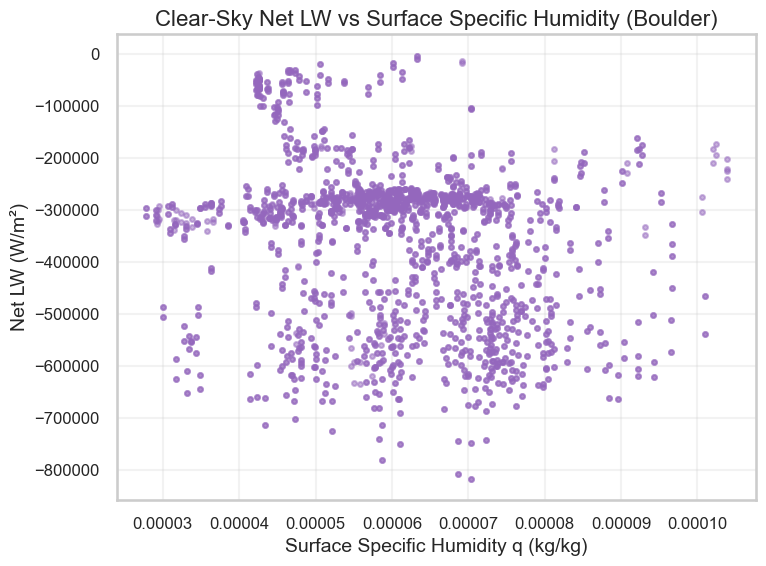

In [163]:
vs.plotting.scatter_net_lw_vs_q(df)
plt.show()

### **5.2 Prepare LW↓ map data**

In [164]:
import xarray as xr

era_map = xr.open_dataset("data/ERA5_sept2020/era5_LW_NA_1deg_sept2020.nc")

lon, lat, LW, lon_min, lon_max, lat_min, lat_max = vs.prepare_lw_down_map(era_map)

### **5.3 Map of LW↓ Over North America**

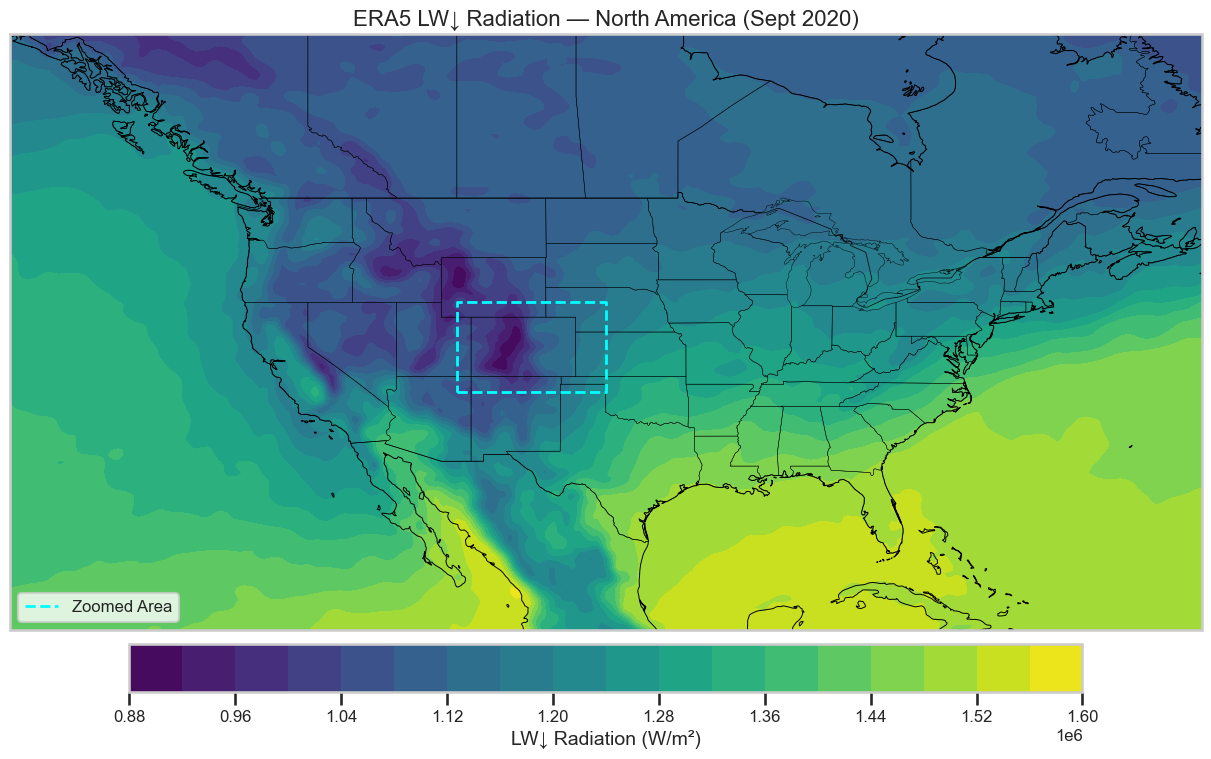

In [165]:
fig = vs.plotting.map_lw_down(
    lon,
    lat,
    LW,
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max(),
)
plt.show()


### **5.4 Colorado zoom map**

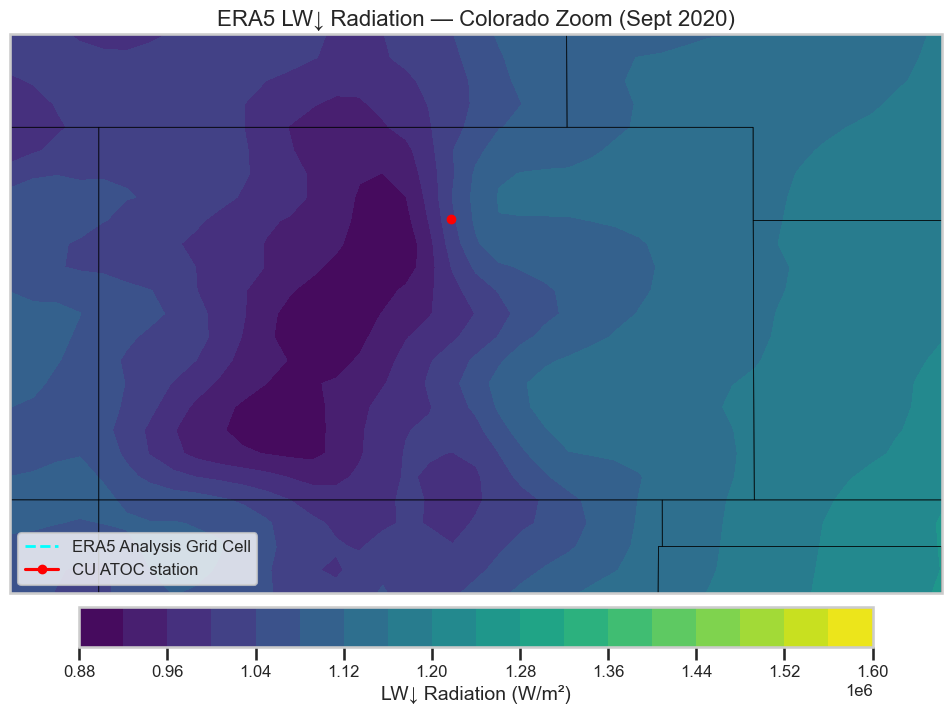

In [166]:
fig = vs.plotting.map_lw_down_zoom(
    lon,
    lat,
    LW,
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max(),
)
plt.show()

## **6. Save Outputs**

Write summary statistics to a text file for reproducibility.

In [167]:
import os
os.makedirs("figures", exist_ok=True)

In [168]:
with open("figures/statistics.txt", "w") as f:
    f.write(str(stats))

## **7. Notes & Limitations**

### **Scientific Notes**

- **ERA5 longwave radiation fields** used here represent *accumulated energy* (J/m²) over each model time step, not instantaneous fluxes (W/m²).  
  For this project, the focus was on **relative differences**—humid vs dry, clear vs cloudy—where the patterns remain physically meaningful.

- **Boulder’s elevation (~850 hPa)** means the “surface vs 850 hPa” humidity comparison is not a clean vertical contrast.  
  The pressure levels are too close together, so the free‑tropospheric signal is muted.  
  With more time, I would use **925 hPa** or analyze a **lower‑elevation site**.

- **CU ATOC pyrgeometer data were not used.**  
  The station operates a **pyrgeometer**, which measures downwelling longwave radiation at **high frequency** (≈1‑second resolution).  
  These data are stored separately, require **quality‑control flags**, and must be **resampled from seconds to hourly means** before merging with ERA5.  
  A future extension would incorporate the pyrgeometer observations to evaluate ERA5 biases under clear and cloudy conditions.

- The analysis focuses on **September 2020 only**.  
  Extending to multiple months or seasons would improve statistical robustness and reveal seasonal patterns.


## **8. Conclusion**

This notebook demonstrated:

- Loading and merging multi‑source datasets
- A clean, modular workflow for analyzing LW–humidity relationships  
- Real diagnostics from ERA5 + CU ATOC data  
- Visualizations showing how humidity and cloudiness modulate longwave radiation, and Cartopy‑based LW↓ maps
- A reproducible scientific pipeline packaged as `vaporspec`  

This completes the demonstration.
